# 第86课 · 给 AI 一点"任性"——temperature / top-k / top-p 采样（sampling）纯 NumPy 从零实现

**学习目标**
- 理解为什么贪婪解码（Greedy Decoding）容易产生重复
- 实现 temperature scaling、top-k、top-p（nucleus）采样
- 直观对比三种策略的分布形状
- 与 aurora.llm.sample 对比验证

> 温度 = logits 尖锐度（$T\to 0$ 近贪婪，$T$ 大更随机）；top-p 自适应候选核。

← **上一课**　[L85 · KV-Cache 从零实现](L85_kv_cache.ipynb)

> 上节课学习了 **KV-Cache 从零实现**：键值缓存矩阵更新，O(seq²)→O(seq) 加速。  
> 本课将探讨 **采样策略从零实现**。

## 为什么 AI 有时会越说越重复？

给 GPT 看“天空是”，贪婪解码（Greedy Decoding）会选“蓝色”——因为“蓝色”概率最高。但下一步，给“天空是蓝色”，它可能又选“蓝色”……于是句子会越滚越长，最后卡在重复里。

**问题的根源**：贪婪解码每一步都只挑概率最大的 token，路径虽然最稳，却也最容易在局部最优里打转，最后把自己绕成重复句。

**解决思路**：不要把概率分布压得太死，而是给它留一点“呼吸空间”，让低概率 token 也有机会被选中。三种常见策略：

```
Temperature T：logits ÷ T
  T < 1 → 分布更尖锐，更保守   （T=0 = 贪婪）
  T > 1 → 分布更平坦，更随机   （T=∞ = 均匀随机）

Top-k 采样：只保留概率最高的 k 个 token，其余设为 -∞
  k=1  → 贪婪；k=vocab_size → 全分布
  问题：k 是固定的，不管分布尖不尖锐

Top-p / Nucleus 采样（Holtzman 2020）：保留累积概率 ≥ p 的最小 token 集
  分布尖锐时（一个 token 压倒性）→ 核很小（只含1-2个）
  分布平坦时（选择均匀）        → 核很大（含许多候选）
```

**公式（Top-p 核构建）**：
1. 排序：按 prob 从大到小排列所有 token
2. 累积：`cumsum = [p₁, p₁+p₂, ...]`
3. 截断：找第一个使 cumsum ≥ p 的位置 → 这些 token 组成 nucleus
4. 从 nucleus 重新 softmax 采样

本节实现 `top_k_sample` 和 `top_p_sample`，纯 NumPy，与 `aurora.llm.sample` 验证对齐。

## ⚠️ 常见误解 (Common Pitfall)

> 不要以为采样能让模型"更聪明"或"答得更准"。这三种策略都不改变模型给出的概率 `probs`，也不会凭空造出新信息——它们只是在决定**从这份概率里怎么挑一个 token**：贪婪永远挑最高的（易重复），temperature/top-k/top-p 则允许挑到长尾候选（更有多样性）。它们调的是"确定性 ↔ 随机性"这个旋钮，不是"质量"旋钮。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
def softmax(logits, temperature=1.0):
    """数值稳定的 softmax，带 temperature 缩放。"""
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits / max(float(temperature), 1e-8)
    logits -= logits.max()
    exp = np.exp(logits)
    return exp / exp.sum()

# 测试 logit 分布
VOCAB = 20
logits = np.random.randn(VOCAB) * 2   # 模拟尖锐分布

print('Temperature 对分布的影响：')
for T in [0.5, 1.0, 2.0]:
    probs = softmax(logits, T)
    entropy = -np.sum(probs * np.log(probs + 1e-30))
    print(f'  T={T}: max_prob={probs.max():.3f}, entropy={entropy:.2f}')

Temperature 对分布的影响：
  T=0.5: max_prob=0.525, entropy=0.96
  T=1.0: max_prob=0.357, entropy=1.84
  T=2.0: max_prob=0.188, entropy=2.60


## ✏️ 任务 1：Top-k 采样

**签名**：
```python
def top_k_sample(logits, k=10, temperature=1.0) -> int:
    # 返回：采样的 token index（整数）
```

**3步实现路线**：

| 步骤 | 操作 | 代码提示 |
|---|---|---|
| 1 | 找 top-k 索引 | `np.argpartition(logits, -k)[-k:]` |
| 2 | 其余 token 设为 -inf | 新数组 `masked = -inf * ones`，再把 top-k 位置填回原 logit |
| 3 | softmax + 采样 | `softmax(masked, temperature)` → `np.random.choice(vocab, p=probs)` |

**验收标准**：
- 返回值是整数，在 top-k 集合内
- `k=1` 等价于贪婪解码（温度=1时）

In [4]:
def top_k_sample(logits, k=10, temperature=1.0):
    """从前 k 个 logit 最大的 token 中采样。"""
    logits = np.asarray(logits, dtype=np.float64)
    k = max(1, min(k, len(logits)))
    # ✏️ TODO: 找到 top-k 索引，其余设为 -inf，softmax，采样
    raise NotImplementedError("TODO")

## ✏️ 任务 2：Top-p（Nucleus）采样

**签名**：
```python
def top_p_sample(logits, p=0.9, temperature=1.0) -> int:
    # 返回：采样的 token index（整数）
```

**4步实现路线**：

| 步骤 | 操作 | 代码提示 |
|---|---|---|
| 1 | softmax → probs | `probs = softmax(logits, temperature)` |
| 2 | 按 prob 降序排列 | `sorted_idx = np.argsort(probs)[::-1]` |
| 3 | 累积概率，找截断点 | `cumsum = np.cumsum(sorted_probs)` → `np.searchsorted(cumsum, p) + 1` |
| 4 | nucleus 中重归一化采样 | `nucleus = sorted_idx[:cutoff]`；在 nucleus probs 上 `np.random.choice` |

**验收标准**：
- 返回值是整数，在 nucleus token 集合内
- `p=1.0` 覆盖全词表（等价于纯 temperature 采样）

In [5]:
def top_p_sample(logits, p=0.9, temperature=1.0):
    """从累积概率 >= p 的最小 token 集中采样。"""
    logits = np.asarray(logits, dtype=np.float64)
    probs = softmax(logits, temperature)
    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    # ✏️ TODO: 累积求和，找到第一个 >= p 的位置
    raise NotImplementedError("TODO")

⬜ 请先实现 top_k_sample / top_p_sample，再运行可视化


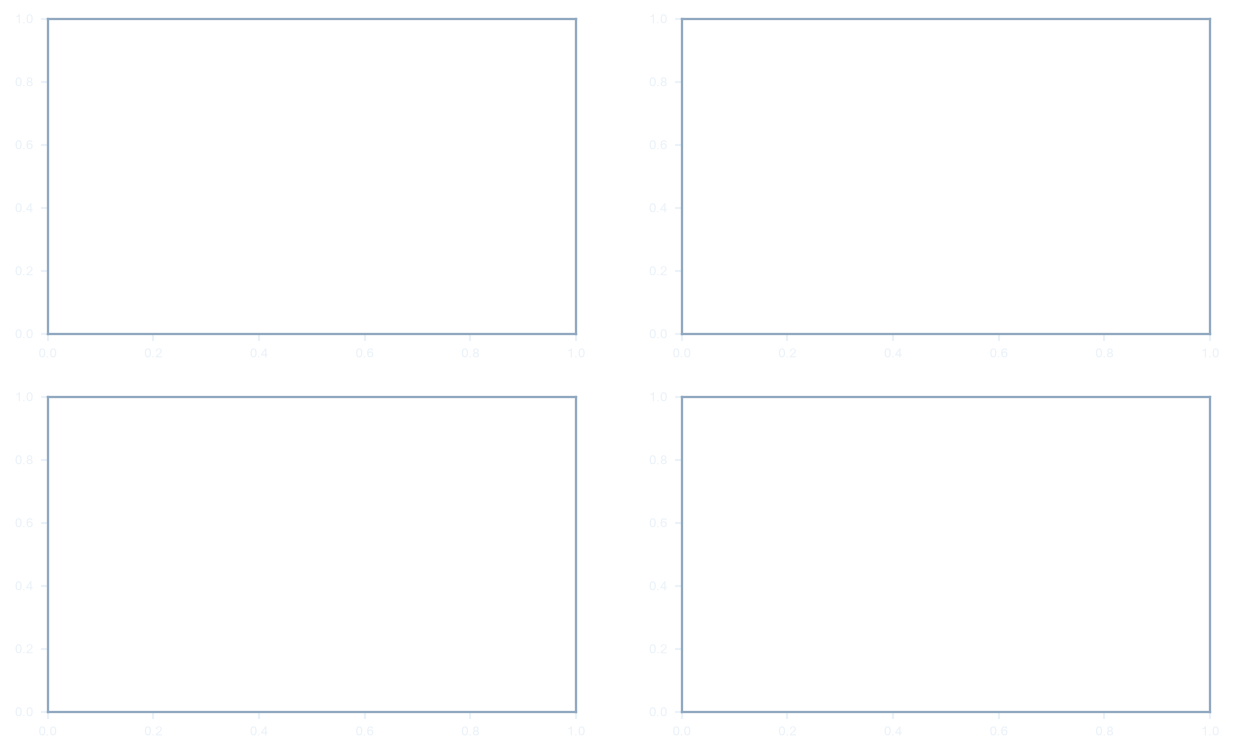

In [6]:
try:
    # 可视化四种策略的采样分布
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    probs_base = softmax(logits, 1.0)
    axes = axes.flatten()

    strategies = [
        ('Greedy', [np.argmax(logits)]),
        ('Temperature T=0.5', [top_k_sample(logits, k=VOCAB, temperature=0.5) for _ in range(500)]),
        ('Top-k k=5', [top_k_sample(logits, k=5) for _ in range(500)]),
        ('Top-p p=0.9', [top_p_sample(logits, p=0.9) for _ in range(500)]),
    ]

    for ax, (name, samples) in zip(axes, strategies):
        counts = np.bincount(samples, minlength=VOCAB) / max(len(samples), 1)
        ax.bar(range(VOCAB), counts, alpha=0.7, label='sample freq')
        ax.plot(range(VOCAB), probs_base, 'r--', alpha=0.5, label='base prob')
        ax.set_title(name, fontsize=10)
        ax.set_xlabel('Token ID')
        ax.set_ylabel('频率')
        ax.legend(fontsize=8)

    plt.suptitle('四种采样策略对比（vocab_size=20）', fontsize=12)
    plt.tight_layout()
    plt.show()
    print('✅ 采样分布可视化完成')
except (NotImplementedError, TypeError):
    print('⬜ 请先实现 top_k_sample / top_p_sample，再运行可视化')


In [7]:
try:
    # 测试 top_k_sample 返回值在 top-k 集合内
    test_logits = np.random.randn(50)
    k = 10
    result_topk = top_k_sample(test_logits, k=k)
    assert result_topk is not None, "⬜ 未实现"
    assert isinstance(result_topk, (int, np.integer)), f"应返回整数索引，得到 {type(result_topk)}"
    top_k_indices = set(np.argpartition(test_logits, -k)[-k:].tolist())
    assert result_topk in top_k_indices, f"返回值 {result_topk} 不在 top-{k} 集合内"
    print(f'✅ top_k_sample 返回: {result_topk}（在 top-{k} 集合内）')

    # 测试 top_p_sample 返回合法索引，并落在 nucleus 内
    result_topp = top_p_sample(test_logits, p=0.9)
    assert result_topp is not None, "⬜ 未实现"
    assert isinstance(result_topp, (int, np.integer)), f"应返回整数索引，得到 {type(result_topp)}"
    assert 0 <= result_topp < len(test_logits), f"返回值 {result_topp} 超出范围"

    probs = np.exp(test_logits - test_logits.max())
    probs /= probs.sum()
    sorted_idx = np.argsort(probs)[::-1]
    cumsum = np.cumsum(probs[sorted_idx])
    cutoff = np.searchsorted(cumsum, 0.9) + 1
    nucleus = set(sorted_idx[:cutoff].tolist())
    assert result_topp in nucleus, f"返回值 {result_topp} 不在 nucleus {nucleus} 内"
    print(f'✅ top_p_sample 返回: {result_topp}（在 nucleus 内）')

    # 与 aurora.llm 对比
    from aurora.llm import top_k_sample as ref_topk
    ref_result = ref_topk(test_logits, k=k)
    ref_top_k_indices = set(np.argpartition(test_logits, -k)[-k:].tolist())
    assert ref_result in ref_top_k_indices, f"aurora.llm 参考实现返回值 {ref_result} 不在 top-{k} 集合内"
    print('✅ 采样策略验证通过')
except (NotImplementedError, TypeError):
    print('⬜ 未实现')

⬜ 未实现


## 本课收束

| 策略 | 参数 | 效果 |
|---|---|---|
| 贪婪 | 无 | 确定性，容易重复 |
| Temperature | T | T<1 更尖锐，T>1 更随机 |
| Top-k | k | 固定候选数量 |
| Top-p | p | 自适应候选集，置信高→小核 |

实际 LLM 通常组合使用：`top_p_sample(logits, p=0.9, temperature=0.8)`。

下一步 L87：先讲 8-bit 量化原理，再把它接到 HuggingFace 上跑真实推理。

## ✏️ 闭卷推导检查格 — top-p Nucleus 推导

**规则：关闭上方所有格，仅凭记忆完成以下推导。**

**题目**：给定 logits = [2.0, 1.0, 0.5, 0.1, -1.0]（词表大小 5），p = 0.9

1. 写出 softmax 计算步骤（含数值稳定处理）
2. 按概率从大到小排序，填写累积概率表：

| 排名 | token index | prob | cumsum |
|------|------------|------|--------|
| 1 | | | |
| 2 | | | |
| 3 | | | |

3. p=0.9 的 nucleus 集合是哪些 token index？

（在此处写推导...）

In [8]:
# 验证：手算结果与 aurora.llm.sample 一致
import numpy as np, sys; sys.path.insert(0, 'src')
from aurora.llm.sample import top_p_sample

logits = np.array([2.0, 1.0, 0.5, 0.1, -1.0])
p = 0.9

# 手动重建 nucleus
probs = np.exp(logits - logits.max())
probs /= probs.sum()
sorted_idx = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_idx]
cumsum = np.cumsum(sorted_probs)

# nucleus = 所有使 cumsum ≤ p 的 token + 第一个超过 p 的 token
cutoff = np.searchsorted(cumsum, p) + 1
nucleus_tokens = set(sorted_idx[:cutoff].tolist())

print("Nucleus token indices:", sorted(nucleus_tokens))
print("Cumulative probs:", [f"{c:.3f}" for c in cumsum[:cutoff]])

# 多次采样，验证结果始终在 nucleus 内
np.random.seed(99)
for _ in range(200):
    sampled = top_p_sample(logits, p=p)
    assert sampled in nucleus_tokens, f"采样结果 {sampled} 不在 nucleus {nucleus_tokens}"
print(f"✅ top-p nucleus 验证通过（200次采样均在 nucleus 内）")

Nucleus token indices: [0, 1, 2, 3]
Cumulative probs: ['0.559', '0.764', '0.889', '0.972']
✅ top-p nucleus 验证通过（200次采样均在 nucleus 内）


In [ ]:
# ✏️ 本课自评
l86_review = {
    "greedy_problem":            None,  # 理解贪婪解码的重复问题：确定性→局部最优？True/False
    "temperature_intuition":     None,  # 理解temperature：T<1尖锐/T>1平坦，T=0=贪婪？True/False
    "top_k_impl":                None,  # top_k_sample实现正确：返回值在top-k集合内？True/False
    "top_p_impl":                None,  # top_p_sample实现正确：nucleus覆盖≥p的最小集？True/False
    "whiteboard_passed":         None,  # 白板挑战top-p核推导通关？True/False
}

unfilled = [k for k, v in l86_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l86_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L86 全部通关！进入 L87：量化与本地推理')

---

→ **下一课**　[L87 · 量化与本地推理](L87_local_inference.ipynb)

> 下节课将学习 **量化与本地推理**：8-bit 量化原理，连接 HuggingFace 轻量推理。